# img2tag_norm

공간 이미지 → mood_tag 튜플 반환. 프론트 연동용 — 하드코딩 경로 없음.

```
이미지 (파일경로 / PIL Image / bytes 모두 가능)
  → Gemini 1.5-flash → 공간 분위기 설명 문장
  → sentence-transformers → 임베딩
  → 코사인 유사도 vs cocktail mood_tag 임베딩
  → (emotion, visual, space) 튜플 반환
```

**설치 (최초 1회)**
```bash
pip install google-generativeai sentence-transformers pillow
```

**환경변수 설정**
```bash
export GEMINI_API_KEY="your_api_key_here"
```

In [1]:
import sys
!{sys.executable} -m pip install google-genai sentence-transformers pillow python-dotenv

In [2]:
import os
import io
import pathlib
import numpy as np
import pandas as pd
from PIL import Image as PILImage
from IPython.display import Image, display
from google import genai
from sentence_transformers import SentenceTransformer

/home/piai/anaconda3/envs/test_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ── 경로 설정 ──────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = pathlib.Path().resolve()
CSV_PATH     = NOTEBOOK_DIR / "../../data/cocktails_final.csv"
EMBED_PATH   = NOTEBOOK_DIR / "cocktail_embeddings_st.npy"
IDS_PATH     = NOTEBOOK_DIR / "cocktail_ids_st.npy"

df = pd.read_csv(CSV_PATH)

# ── Gemini 설정 ────────────────────────────────────────────────────────────────
from dotenv import load_dotenv
load_dotenv(NOTEBOOK_DIR / "../../../.env")

GEMINI_API_KEY = os.environ.get("GOOGLE_API_KEY", "")
client = genai.Client(api_key=GEMINI_API_KEY)

# ── 임베딩 모델 ────────────────────────────────────────────────────────────────
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
print("모델 로드 완료")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4711.72it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


모델 로드 완료


In [4]:
# ── cocktail 임베딩 사전 계산 (npy 있으면 스킵) ───────────────────────────────
if EMBED_PATH.exists() and IDS_PATH.exists():
    cocktail_embeddings = np.load(EMBED_PATH)
    cocktail_ids        = np.load(IDS_PATH)
    print(f"[스킵] 임베딩 로드: {cocktail_embeddings.shape}")
else:
    print("mood_tag 임베딩 계산 중...")
    tags = df["mood_tag"].str.replace("|", " ", regex=False).tolist()
    cocktail_embeddings = embed_model.encode(tags, show_progress_bar=True)
    cocktail_ids        = df["cocktail_id"].values
    np.save(EMBED_PATH, cocktail_embeddings)
    np.save(IDS_PATH,   cocktail_ids)
    print(f"저장 완료: {cocktail_embeddings.shape}")

[스킵] 임베딩 로드: (101, 384)


In [5]:
# ── 사용 가능한 모델 목록 확인 ────────────────────────────────────────────────
for m in client.models.list():
    if "generateContent" in (m.supported_actions or []):
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [6]:
def _to_pil(image_input) -> PILImage.Image:
    """파일경로(str/Path), PIL Image, bytes 모두 수용"""
    if isinstance(image_input, PILImage.Image):
        return image_input.convert("RGB")
    if isinstance(image_input, (bytes, bytearray)):
        return PILImage.open(io.BytesIO(image_input)).convert("RGB")
    return PILImage.open(image_input).convert("RGB")


def analyze_image(image_input) -> str:
    """Gemini로 공간 분위기 설명 문장 생성"""
    pil_img = _to_pil(image_input)
    prompt = (
        "Describe the mood and atmosphere of this space in 1-2 sentences. "
        "Focus on the emotional vibe (e.g. cozy, lively, romantic), "
        "the lighting and visual tone (e.g. warm, bright, dark), "
        "and the sense of space (e.g. intimate, open, casual). "
        "Do not describe objects."
    )
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[prompt, pil_img]
    )
    return response.text.strip()


def img2tag(image_input) -> tuple:
    """
    이미지를 받아 mood_tag 튜플 반환.

    Parameters
    ----------
    image_input : str | Path | PIL.Image | bytes

    Returns
    -------
    tuple  예: ("lively", "bright", "spacious")
    """
    vlm_text  = analyze_image(image_input)
    query_emb = embed_model.encode(vlm_text)

    norms = np.linalg.norm(cocktail_embeddings, axis=1) * np.linalg.norm(query_emb)
    sims  = cocktail_embeddings @ query_emb / np.where(norms == 0, 1e-9, norms)

    best_cid = cocktail_ids[int(np.argmax(sims))]
    mood_tag = df[df["cocktail_id"] == best_cid].iloc[0]["mood_tag"]
    return tuple(mood_tag.split("|"))

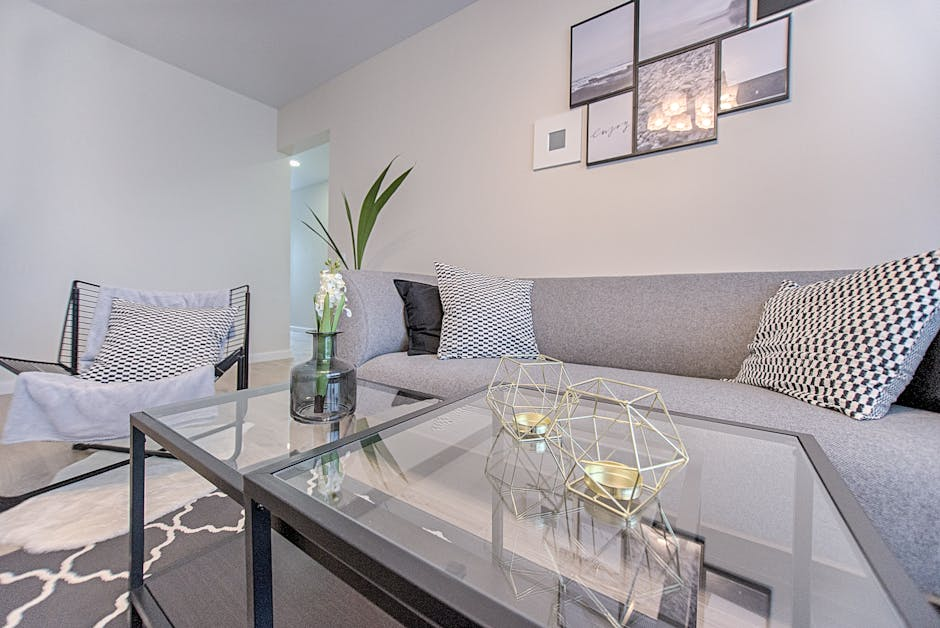

분위기 설명 → This space evokes a tranquil and casually modern atmosphere, characterized by bright, even lighting and an inviting sense of sophisticated comfort.
mood_tag   → ('lively', 'bright', 'spacious')


In [7]:
# ── 사용 예시 ─────────────────────────────────────────────────────────────────
IMAGE_PATH = "/home/piai/다운로드/mood_tag/data/image_182.jpg"   # ← 여기만 바꾸세요

display(Image(filename=IMAGE_PATH, width=400))

description = analyze_image(IMAGE_PATH)
print(f"분위기 설명 → {description}")

tag = img2tag(IMAGE_PATH)
print(f"mood_tag   → {tag}")